# 실험의 전제와 목표

1. **전제** 
    - ImageNet으로 사전학습된 세 모델 ResNet, DenseNet, EfficientNet 각각을 전이학습한다. 
    - 전이학습 방법으로는 Feature Extraction, Partial Fine-Tuning, Full Fine-Tuning을 진행한다. 
    - 이미지 전처리 전략으로는 4 가지를 둔다.
    - 학습은 무료 구독 colab GPU T4에서 진행한다. 
    - 로컬 환경은 mps.

2. **목표**
    - 폐렴 예측 과제를 가장 잘 수행하는 **모델 x 전이학습 조합**을 확인한다. 
    - 그 조합에서 사용된 **데이터셋 전처리 전략**은 무엇이었는 지 확인한다. 
    - 결과에 대해 **설명**할 수 있다. 

    - ***여유가 되면 추가***: U-Net **Image segmentation** 이용해 폐 부분을 먼저 crop한 후에 이미지 전처리 파이프라인을 통과시킨다.
        - Image segmentation을 활용한 데이터 전처리의 효과를 점검한다. 
- **실험 대상 전이학습 방법**
    | 학습 방법 | 정의 | 
    | -- | -- |
    | Feature Extraction(Frozen) | 특징 추출기 부분은 완전히 고정하고, 분류기 부분만 ImageNet 가중치 위에서 fine-tuning한다. 
    | Paritial Fine-Tuning | 특징 추출기의 마지막 stage 하나와 분류기 head를 제외한 부분은 freeze. ImageNet 사전학습 가중치 위에서 재학습한다. |
    | Full Fine-Tuning | 모든 가중치를 ImageNet 사전학습 가중치 위에서 Fine-Tuning 한다. | 

- **실험 대상 데이터 전처리 방법** 
    | 전처리 방법 | Channel | Sizing | Equalization | Augmentation | Normalization | 
    | -- | -- | -- | -- | -- | -- |
    | 1ch__clahe | 1채널 | 비율 유지 패딩 | CLAHE O | rotation + Hflip | ImageNet 통계 기준 |
    | 1ch__none | 1채널 | 비율 유지 패딩 | CLAHE X | rotation + Hflip | ImageNet 통계 기준 |
    | 3ch__clahe | 3채널 | 비율 유지 패딩 | CLAHE O | rotation + Hflip | ImageNet 통계 기준 |
    | 3ch__none | 3채널 | 비율 유지 패딩 | CLAHE X | rotation + Hflip | ImageNet 통계 기준 |

# 0. 공통 실험 인프라 구축
- 상수 모음
- 시드 고정
- colab(cuda)/로컬(mps) 디바이스 설정
- colab/로컬 환경 data/result 드라이브 마운트/경로 설정
- 평가 함수(Accuracy, Precision, Recall, F1, confusion matrix, ROC-AUC)
- best-eval checkpoint 저장이 포함된 train/evaluate 함수

In [1]:
# ---------- import ----------
import copy
import hashlib
import os
import random
import re
import sys
import time
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from sklearn.metrics import (accuracy_score, confusion_matrix, precision_recall_fscore_support,
                             roc_auc_score)
from sklearn.model_selection import StratifiedGroupKFold
from torch.utils.data import WeightedRandomSampler

# ---------- 상수 ----------
SEED = 42
IMG_SIZE = 224
SPLITS = ["train", "val", "test"]
CLASSES = ["NORMAL", "PNEUMONIA"]          # label index: NORMAL=0, PNEUMONIA=1(positive)
POS_LABEL = 1

# 정규화: 3채널은 ImageNet 채널별 통계, 1채널은 ImageNet 3채널 통계의 평균
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
GRAY_MEAN = float(np.mean(IMAGENET_MEAN))  # 0.449
GRAY_STD = float(np.mean(IMAGENET_STD))    # 0.226

# 데이터 분할 / 전처리 / 증강
VAL_RATIO = 0.1                    # train+val : test ≈ 9:1 이므로 train:val도 9:1
CLAHE_CLIP, CLAHE_TILE = 2.0, (8, 8)  # EDA 3-5와 동일
ROT_DEG = 10                       # 랜덤 회전 범위(±deg)
HFLIP_P = 0.5

BATCH_SIZE = 32

In [2]:
# ---------- 시드 고정 ----------
def seed_everything(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(SEED)

In [3]:
# ---------- 디바이스: colab(cuda) / 로컬(mps) ----------
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

# ---------- 경로: colab은 Drive 마운트, 로컬은 현재 폴더 ----------
IN_COLAB = "google.colab" in sys.modules
DRIVE_PROJECT = "CodeIT/Colab/mission6_xray"  # MyDrive 아래 프로젝트 폴더명

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_DIR = Path("/content/drive/MyDrive") / DRIVE_PROJECT
else:
    PROJECT_DIR = Path(".")

DATA_DIR = PROJECT_DIR / "data"
RESULT_DIR = PROJECT_DIR / "results"
CACHE_DIR = RESULT_DIR / "cache"            # 전처리 캐시(npz)
CKPT_DIR = RESULT_DIR / "checkpoints"       # best-eval checkpoint
TB_DIR = RESULT_DIR / "runs"                # TensorBoard 로그
for d in (CACHE_DIR, CKPT_DIR, TB_DIR):
    d.mkdir(parents=True, exist_ok=True)

assert DATA_DIR.exists(), f"데이터 폴더가 없습니다: {DATA_DIR.resolve()}"
print(f"device={DEVICE}, colab={IN_COLAB}")
print(f"DATA_DIR={DATA_DIR.resolve()}\nRESULT_DIR={RESULT_DIR.resolve()}")

device=mps, colab=False
DATA_DIR=/Users/raewookang/Codeit_Missions/CodeItFinetuningForXRay/data
RESULT_DIR=/Users/raewookang/Codeit_Missions/CodeItFinetuningForXRay/results


In [4]:
# ---------- 평가 함수 ----------
def compute_metrics(y_true, y_prob, threshold: float = 0.5) -> dict:
    """PNEUMONIA(=1)를 positive로 보고 Accuracy / Precision / Recall / F1 / ROC-AUC / confusion matrix를 계산한다."""
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", pos_label=POS_LABEL, zero_division=0)
    # 한 클래스만 있는 배치/부분집합에서는 AUC가 정의되지 않는다
    roc_auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) == 2 else float("nan")
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=[0, 1]),
    }


def plot_confusion_matrix(cm, title: str = "", ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(3.6, 3.2))
    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_xticks([0, 1], CLASSES)
    ax.set_yticks([0, 1], CLASSES)
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.set_title(title)
    return ax

In [5]:
# ---------- TensorBoard (colab은 기본 설치, 로컬은 pip install tensorboard) ----------
try:
    from torch.utils.tensorboard import SummaryWriter
except ImportError:
    SummaryWriter = None
    print("tensorboard 미설치: 학습 기록은 history DataFrame에만 남습니다.")


def make_writer(run_name: str):
    return SummaryWriter(log_dir=str(TB_DIR / run_name)) if SummaryWriter else None


# ---------- train / evaluate ----------
# 모델은 2-class logits (B, 2)를 출력한다고 가정한다. loader는 (x, y)를 device 위 텐서로 준다.
def train_one_epoch(model, loader, criterion, optimizer, device=DEVICE):
    model.train()
    total_loss, n_correct, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * y.size(0)
        n_correct += (logits.argmax(1) == y).sum().item()
        n += y.size(0)
    return {"loss": total_loss / n, "accuracy": n_correct / n}


@torch.no_grad()
def evaluate(model, loader, criterion, device=DEVICE, threshold: float = 0.5):
    """loss + compute_metrics 결과와, 사후 분석용 y_true / y_prob(PNEUMONIA 확률)를 함께 반환한다."""
    model.eval()
    total_loss, n = 0.0, 0
    y_true, y_prob = [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        total_loss += criterion(logits, y).item() * y.size(0)
        n += y.size(0)
        y_true.append(y.cpu())
        y_prob.append(logits.softmax(1)[:, POS_LABEL].cpu())
    y_true = torch.cat(y_true).numpy()
    y_prob = torch.cat(y_prob).numpy()
    metrics = {"loss": total_loss / n, **compute_metrics(y_true, y_prob, threshold)}
    return metrics, y_true, y_prob


def fit(model, train_loader, val_loader, criterion, optimizer, epochs: int, run_name: str,
        scheduler=None, monitor: str = "f1", writer=None, device=DEVICE):
    """매 에폭 train/val 지표를 모두 기록하고, val `monitor` 지표가 가장 좋은 에폭의 가중치를
    checkpoint로 저장한다. 학습이 끝나면 best 가중치를 모델에 다시 로드하고 history를 반환한다.
    monitor: "f1" | "recall" | "roc_auc" | "precision" | "accuracy" | "loss"(loss만 최소화)
    """
    model.to(device)
    minimize = monitor == "loss"
    best_score = float("inf") if minimize else -float("inf")
    best_state, best_epoch = None, -1
    ckpt_path = CKPT_DIR / f"{run_name}_best.pt"
    history = []

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr = train_one_epoch(model, train_loader, criterion, optimizer, device)
        va, _, _ = evaluate(model, val_loader, criterion, device)
        lr = optimizer.param_groups[0]["lr"]
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(va["loss"])
            else:
                scheduler.step()

        row = {"epoch": epoch, "lr": lr, "train_loss": tr["loss"], "train_accuracy": tr["accuracy"],
               **{f"val_{k}": v for k, v in va.items() if k != "confusion_matrix"},
               "sec": time.time() - t0}
        history.append(row)

        if writer is not None:
            writer.add_scalars("loss", {"train": tr["loss"], "val": va["loss"]}, epoch)
            writer.add_scalars("accuracy", {"train": tr["accuracy"], "val": va["accuracy"]}, epoch)
            for k in ("precision", "recall", "f1", "roc_auc"):
                writer.add_scalar(f"val/{k}", va[k], epoch)
            writer.add_scalar("lr", lr, epoch)

        score = va[monitor]
        # 첫 에폭은 항상 저장한다 (monitor가 NaN이어도 best 가중치가 비지 않도록)
        improved = best_state is None or (score < best_score if minimize else score > best_score)
        if improved:
            best_score, best_epoch = score, epoch
            best_state = copy.deepcopy({k: v.detach().cpu() for k, v in model.state_dict().items()})
            torch.save({"state_dict": best_state, "epoch": epoch, "monitor": monitor,
                        "val_metrics": {k: v for k, v in va.items() if k != "confusion_matrix"}}, ckpt_path)

        print(f"[{run_name}] ep {epoch:02d} | train loss {tr['loss']:.4f} acc {tr['accuracy']:.3f} | "
              f"val loss {va['loss']:.4f} acc {va['accuracy']:.3f} rec {va['recall']:.3f} "
              f"f1 {va['f1']:.3f} auc {va['roc_auc']:.3f} | {row['sec']:.0f}s" + (" *" if improved else ""))

    if writer is not None:
        writer.flush()
    model.load_state_dict(best_state)
    print(f"[{run_name}] best epoch={best_epoch} ({monitor}={best_score:.4f}) -> {ckpt_path}")
    return pd.DataFrame(history)

tensorboard 미설치: 학습 기록은 history DataFrame에만 남습니다.


# 1. 데이터 전처리
- **데이터 재분할:**
    - train+val 합친 후 split한다. 
    - person id 그룹 기준으로 나눈다. 동일 id가 train/val에 섞여들어가지 않도록 한다. 
- **test 해시 기준 중복 이미지 제거**
    - EDA에서 확인한 중복 이미지 6장에서 한 장만 남기고 제거한다. 
- **소수 클래스(NORMAL) 가중치**
    - WeightedRandomSampler를 활용한다. 
- **전처리 데이터셋 변형 정의:**
    - 고정할 것:
        - Size 통일: 비율 유지 padding
            - 근거 1: 폐렴/정상 클래스 간에 종횡비 차이가 크다. 종횡비를 무의미하게 만들어야 할 필요가 있다. 
            - 근거 2: L/R, 심전도 선 및 의료기기로 추정되는 것 등 방해요소가 주변에 있다. 하지만 L/R 마커는 NORMAL, PNEUMONIA 거의 모든 데이터에 존재하고, 의료기기가 같이 찍힌 사진은 그 수가 많지 않다. 
            - Center Crop 우려사항: 폐 주변 정보가 소실될 수 있다. 폐가 아닌 부분이 crop될 수도 있다. 모든 이미지를 crop 후 확인해야 한다. 
            - Resize를 하지 않는 사유: 원본 이미지 자체에 종횡비 차이가 크기 때문에, Resize(224,224)로 늘리면 반죽 펴듯이 이미지가 왜곡될 우려가 있다. 
        - Normalization: ImageNet 통계 기준으로 정규화한다. 
            - 근거: 전이학습 대상 데이터와 ImageNet 통계 데이터 기준 정규화 간에 차이가 거의 없었다. 따라서 사전학습 가중치에 맞는 정규화 방식을 사용하는 것으로 한다. 

    - 변수로 처리할 것:
        - CLAHE: 적용 vs 미적용
        - 채널 통일: 1채널 vs 3채널

    | 전처리 방법 | Channel | Sizing | Equalization | Augmentation | Normalization | 
    | -- | -- | -- | -- | -- | -- |
    | 1 | 1채널 | 비율 유지 패딩 | CLAHE X | rotation + Hflip | ImageNet 통계 기준 |
    | 2 | 1채널 | 비율 유지 패딩 | CLAHE O | rotation + Hflip | ImageNet 통계 기준 |
    | 3 | 3채널 | 비율 유지 패딩 | CLAHE X | rotation + Hflip | ImageNet 통계 기준 |
    | 4 | 3채널 | 비율 유지 패딩 | CLAHE O | rotation + Hflip | ImageNet 통계 기준 |

- **여유가 되면 실험할 것**
    - U-Net Image segmentation 모델을 이용해 폐 부분을 먼저 crop한 후에 이미지 전처리 파이프라인을 통과시키는 실험을 따로 진행한다. 
        - Image segmentation을 활용한 데이터 전처리의 효과를 점검한다. 

In [6]:
# ---------- 메타 수집: 경로 / 라벨 / 환자 그룹 / (test) 픽셀 해시 ----------
PERSON_RE = re.compile(r"person(\d+)_(bacteria|virus)_(\d+)")
NORMAL_RE = re.compile(r"^(.*IM-\d+)-")   # NORMAL은 person id 대신 'IM-0523' 같은 접두가 환자 번호 역할을 한다


def group_key(cls: str, filename: str) -> str:
    m = PERSON_RE.match(filename) if cls == "PNEUMONIA" else NORMAL_RE.match(filename)
    return f"{cls}/{m.group(1)}" if m else f"{cls}/{filename}"   # 매칭 실패 시 단독 그룹


def pixel_md5(path) -> str:
    with Image.open(path) as im:
        return hashlib.md5(np.asarray(im.convert("L")).tobytes()).hexdigest()


def build_meta() -> pd.DataFrame:
    rows = []
    for split in SPLITS:
        for label, cls in enumerate(CLASSES):
            for p in sorted((DATA_DIR / split / cls).glob("*.jpeg")):
                rows.append({"rel_path": f"{split}/{cls}/{p.name}", "orig_split": split, "cls": cls,
                             "label": label, "group": group_key(cls, p.name)})
    meta = pd.DataFrame(rows)
    # 픽셀 해시는 test 중복 제거에만 필요하다 (EDA 5-1과 같은 convert("L") 기준)
    is_test = meta["orig_split"] == "test"
    meta.loc[is_test, "pixel_md5"] = [pixel_md5(DATA_DIR / r) for r in meta.loc[is_test, "rel_path"]]
    return meta


meta = build_meta()
display(pd.crosstab(meta["orig_split"], meta["cls"]).reindex(SPLITS))

cls,NORMAL,PNEUMONIA
orig_split,,
train,1341,3875
val,8,8
test,234,390


In [7]:
# ---------- 데이터 재분할: train+val을 합친 뒤 환자 그룹 단위로 9:1 층화 분할 ----------
pool = meta[meta["orig_split"] != "test"].reset_index(drop=True)
sgkf = StratifiedGroupKFold(n_splits=round(1 / VAL_RATIO), shuffle=True, random_state=SEED)
tr_idx, va_idx = next(sgkf.split(pool, pool["label"], groups=pool["group"]))
train_df = pool.iloc[tr_idx].reset_index(drop=True)
val_df = pool.iloc[va_idx].reset_index(drop=True)

leak = set(train_df["group"]) & set(val_df["group"])
assert not leak, f"train/val에 같은 그룹이 섞였습니다: {list(leak)[:5]}"

ct = pd.DataFrame({name: df["cls"].value_counts().reindex(CLASSES)
                   for name, df in [("train", train_df), ("val", val_df)]}).T
display(pd.concat({"count": ct, "ratio": ct.div(ct.sum(axis=1), axis=0).round(3)}, axis=1)
        .assign(total=ct.sum(axis=1), groups=[train_df["group"].nunique(), val_df["group"].nunique()]))

count            ratio           total groups
cls   NORMAL PNEUMONIA NORMAL PNEUMONIA             
train   1214      3495  0.258     0.742  4709   2577
val      135       388  0.258     0.742   523    284

In [8]:
# ---------- test 해시 기준 중복 이미지 제거: 중복 그룹마다 첫 장만 남긴다 ----------
test_all = meta[meta["orig_split"] == "test"]
dup_mask = test_all.duplicated("pixel_md5", keep="first")
print(f"test: {len(test_all)} -> {len(test_all) - dup_mask.sum()} (중복 {dup_mask.sum()}장 제거)")
display(test_all[test_all.duplicated("pixel_md5", keep=False)]
        .assign(removed=dup_mask)[["rel_path", "cls", "pixel_md5", "removed"]])
test_df = test_all[~dup_mask].reset_index(drop=True)

test: 624 -> 618 (중복 6장 제거)


,rel_path,cls,pixel_md5,removed
5326,test/NORMAL/NORMAL2-IM-0095-0001.jpeg,NORMAL,490238debf98e38314601339655f5d7a,False
5327,test/NORMAL/NORMAL2-IM-0096-0001.jpeg,NORMAL,490238debf98e38314601339655f5d7a,True
5349,test/NORMAL/NORMAL2-IM-0173-0001-0001.jpeg,NORMAL,bcd47182e622a00b47ca8a483736af8c,False
5350,test/NORMAL/NORMAL2-IM-0173-0001-0002.jpeg,NORMAL,bcd47182e622a00b47ca8a483736af8c,True
5370,test/NORMAL/NORMAL2-IM-0246-0001-0001.jpeg,NORMAL,46c9cc352433b6d00234274328e74334,False
5371,test/NORMAL/NORMAL2-IM-0246-0001-0002.jpeg,NORMAL,46c9cc352433b6d00234274328e74334,True
5551,test/PNEUMONIA/person128_bacteria_606.jpeg,PNEUMONIA,2f340970400a806e8a5ee314a48aaf27,False
5552,test/PNEUMONIA/person128_bacteria_607.jpeg,PNEUMONIA,2f340970400a806e8a5ee314a48aaf27,True
5569,test/PNEUMONIA/person134_bacteria_643.jpeg,PNEUMONIA,a285a7d87f39959bf7567703a3b1bab4,False
5570,test/PNEUMONIA/person134_bacteria_644.jpeg,PNEUMONIA,a285a7d87f39959bf7567703a3b1bab4,True


In [9]:
# ---------- 전처리 (a) 결정적 단계를 1회만 계산해 캐시 ----------
# 흑백 변환 -> (CLAHE: 원본 해상도에서 적용) -> 비율 유지 letterbox pad 224.
# 매 에폭 같은 결과가 나오는 단계라 JPEG 디코딩/CLAHE/resize 비용을 학습 루프에서 제거한다.
# 채널 수(1ch/3ch)는 캐시하지 않는다. 두 변형은 같은 캐시를 공유하고 정규화 직전에만 갈린다.
VARIANTS = {  # name: (channels, clahe)
    "1ch__none": (1, False),
    "1ch__clahe": (1, True),
    "3ch__none": (3, False),
    "3ch__clahe": (3, True),
}


def resize_pad(gray: np.ndarray, size: int = IMG_SIZE) -> np.ndarray:
    """긴 변을 size에 맞추고 남는 영역을 0(검정)으로 채운다. EDA 3-6의 resize_pad와 같다."""
    im = Image.fromarray(gray)
    w, h = im.size
    s = size / max(w, h)
    im = im.resize((max(1, round(w * s)), max(1, round(h * s))), Image.BILINEAR)
    canvas = Image.new("L", (size, size), 0)
    canvas.paste(im, ((size - im.width) // 2, (size - im.height) // 2))
    return np.asarray(canvas)


def _preprocess_one(rel_path: str):
    with Image.open(DATA_DIR / rel_path) as im:
        gray = np.asarray(im.convert("L"))
    clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_TILE)  # 스레드마다 별도 객체
    return resize_pad(gray), resize_pad(clahe.apply(gray))


def load_or_build_cache(rel_paths, force: bool = False) -> dict:
    """{"none": uint8 (N,224,224), "clahe": uint8 (N,224,224)}. 순서는 rel_paths와 같다."""
    path = CACHE_DIR / f"preprocessed_{IMG_SIZE}.npz"
    rel_paths = np.asarray(rel_paths)
    if path.exists() and not force:
        z = np.load(path)
        if np.array_equal(z["rel_paths"], rel_paths):
            return {"none": z["none"], "clahe": z["clahe"]}
        print("캐시의 이미지 목록이 달라 다시 만듭니다.")

    t0 = time.time()
    with ThreadPoolExecutor(max_workers=os.cpu_count()) as ex:   # PIL 디코딩/cv2는 GIL을 놓아서 스레드로 병렬화된다
        out = list(ex.map(_preprocess_one, rel_paths, chunksize=32))
    cache = {"none": np.stack([o[0] for o in out]), "clahe": np.stack([o[1] for o in out])}
    np.savez(path, rel_paths=rel_paths, **cache)
    print(f"캐시 생성: {len(rel_paths)}장, {time.time() - t0:.0f}s -> {path}")
    return cache


# train / val / test 전체를 한 배열에 담고, 각 split은 인덱스로 가리킨다
all_df = pd.concat([train_df.assign(split="train"), val_df.assign(split="val"), test_df.assign(split="test")],
                   ignore_index=True)
CACHE = load_or_build_cache(sorted(all_df["rel_path"]))
_pos = {p: i for i, p in enumerate(sorted(all_df["rel_path"]))}
all_df["cache_idx"] = all_df["rel_path"].map(_pos)
print({k: (v.shape, v.dtype, f"{v.nbytes / 1e6:.0f}MB") for k, v in CACHE.items()})

캐시 생성: 5850장, 30s -> results/cache/preprocessed_224.npz
{'none': ((5850, 224, 224), dtype('uint8'), '294MB'), 'clahe': ((5850, 224, 224), dtype('uint8'), '294MB')}


In [10]:
# ---------- 전처리 (b) 데이터 GPU 상주 + (c) 배치 단위 GPU 증강/정규화 ----------
# 모든 모델 x 전이학습 방법 x 전처리 변형이 같은 캐시 -> 같은 증강 -> 같은 sampler를 탄다.
# 증강 난수는 run마다 시드 고정된 전용 Generator(CPU)에서 뽑아, 1ch/3ch 변형이 완전히 같은 증강 샘플을 보게 한다.
_DEVICE_IMAGES = {}   # clahe 여부별로 device에 한 번만 올린다 (1ch/3ch 공유)


def device_images(clahe: bool) -> torch.Tensor:
    key = "clahe" if clahe else "none"
    if key not in _DEVICE_IMAGES:
        _DEVICE_IMAGES[key] = torch.from_numpy(CACHE[key]).unsqueeze(1).to(DEVICE)  # uint8 (N,1,H,W)
    return _DEVICE_IMAGES[key]


class GpuTransform:
    """uint8 (B,1,H,W) -> float 정규화 텐서. train이면 샘플별 회전(±ROT_DEG) + 좌우반전을 한 번의 affine으로 적용한다."""

    def __init__(self, channels: int, train: bool, generator: torch.Generator | None = None):
        self.channels, self.train, self.gen = channels, train, generator
        if channels == 1:
            mean, std = [GRAY_MEAN], [GRAY_STD]
        else:
            mean, std = IMAGENET_MEAN, IMAGENET_STD
        self.mean = torch.tensor(mean, device=DEVICE).view(1, -1, 1, 1)
        self.std = torch.tensor(std, device=DEVICE).view(1, -1, 1, 1)

    def augment(self, x):
        b = x.size(0)
        # 배치 전체가 아니라 샘플마다 각도/반전을 따로 뽑는다
        angle = (torch.rand(b, generator=self.gen) * 2 - 1) * np.deg2rad(ROT_DEG)
        flip = torch.where(torch.rand(b, generator=self.gen) < HFLIP_P, -1.0, 1.0)
        cos, sin = torch.cos(angle), torch.sin(angle)
        theta = torch.zeros(b, 2, 3)
        theta[:, 0, 0], theta[:, 0, 1] = cos * flip, -sin
        theta[:, 1, 0], theta[:, 1, 1] = sin * flip, cos
        grid = F.affine_grid(theta.to(x.device), list(x.shape), align_corners=False)
        return F.grid_sample(x, grid, mode="bilinear", padding_mode="zeros", align_corners=False)  # 바깥은 배경 0

    def __call__(self, x_uint8):
        x = x_uint8.float().div_(255)
        if self.train:
            x = self.augment(x)
        if self.channels == 3:
            x = x.expand(-1, 3, -1, -1)
        return (x - self.mean) / self.std


class GpuBatchLoader:
    """device에 올라간 이미지 텐서에서 인덱스로 배치를 꺼낸다. DataLoader의 워커/collate/전송 비용이 없다."""

    def __init__(self, images, indices, labels, transform, batch_size=BATCH_SIZE, sampler=None):
        self.images = images
        self.indices = torch.tensor(indices, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.labels_dev = self.labels.to(DEVICE)
        self.transform, self.batch_size, self.sampler = transform, batch_size, sampler

    def __len__(self):
        n = len(self.sampler) if self.sampler is not None else len(self.indices)
        return (n + self.batch_size - 1) // self.batch_size

    def __iter__(self):
        order = (torch.as_tensor(list(self.sampler), dtype=torch.long) if self.sampler is not None
                 else torch.arange(len(self.indices)))
        for s in range(0, len(order), self.batch_size):
            pos = order[s:s + self.batch_size]
            x = self.images[self.indices[pos].to(DEVICE)]
            yield self.transform(x), self.labels_dev[pos.to(DEVICE)]


def make_loaders(variant: str, batch_size: int = BATCH_SIZE, seed: int = SEED):
    """variant: VARIANTS의 키. train은 WeightedRandomSampler(클래스 역빈도)로 NORMAL을 더 자주 뽑는다."""
    channels, clahe = VARIANTS[variant]
    images = device_images(clahe)
    aug_gen = torch.Generator().manual_seed(seed)
    sampler_gen = torch.Generator().manual_seed(seed)

    loaders = {}
    for split in ["train", "val", "test"]:
        df = all_df[all_df["split"] == split]
        is_train = split == "train"
        sampler = None
        if is_train:
            class_w = 1.0 / np.bincount(df["label"], minlength=len(CLASSES))
            sampler = WeightedRandomSampler(class_w[df["label"].to_numpy()], num_samples=len(df),
                                            replacement=True, generator=sampler_gen)
        loaders[split] = GpuBatchLoader(images, df["cache_idx"].to_numpy(), df["label"].to_numpy(),
                                        GpuTransform(channels, train=is_train, generator=aug_gen if is_train else None),
                                        batch_size=batch_size, sampler=sampler)
    return loaders

1ch__none   shape=(32, 1, 224, 224) mean=-0.378 std=1.276
1ch__clahe  shape=(32, 1, 224, 224) mean=-0.323 std=1.301
3ch__none   shape=(32, 3, 224, 224) mean=-0.377 std=1.284
3ch__clahe  shape=(32, 3, 224, 224) mean=-0.322 std=1.309


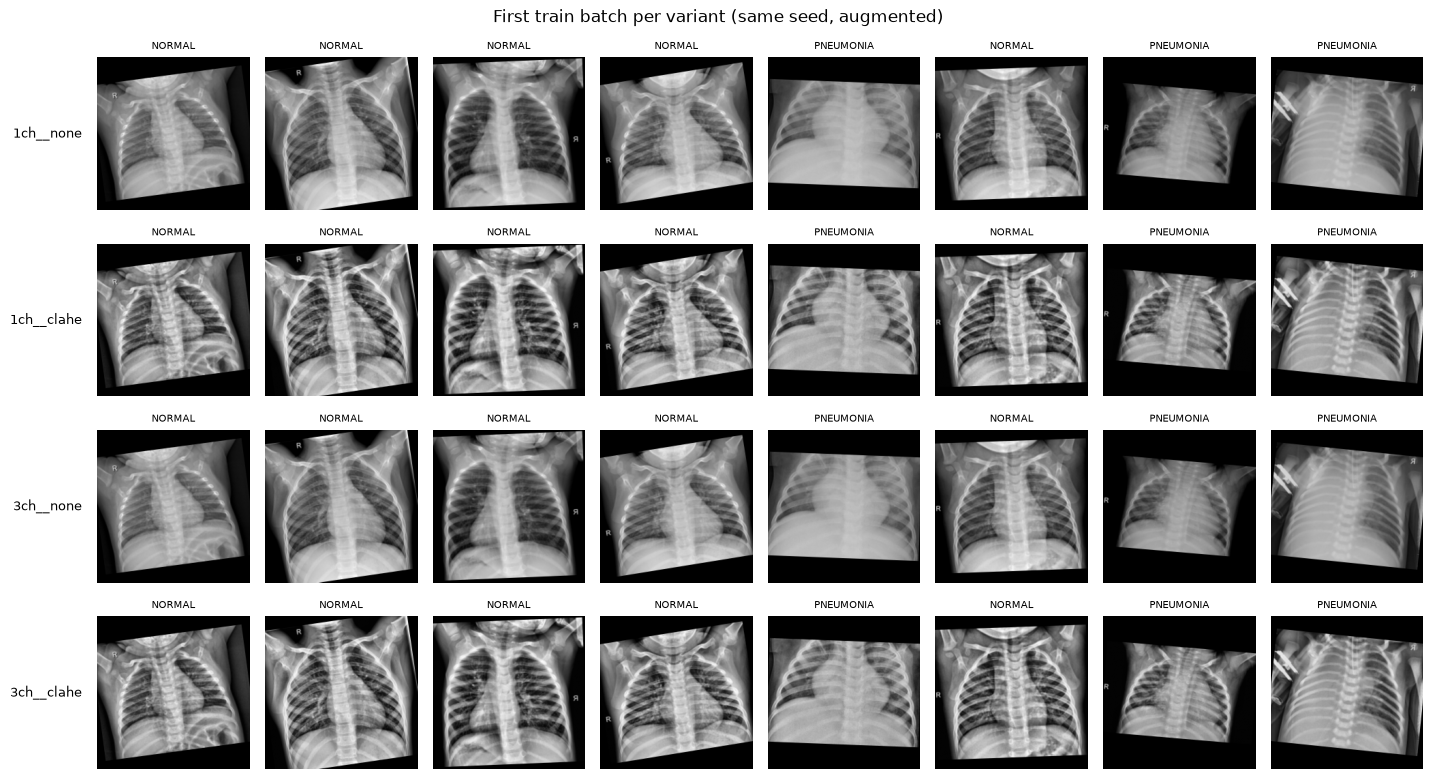

1ch vs 3ch (none) max abs diff = 1.19e-07
1ch vs 3ch (clahe) max abs diff = 1.19e-07
train epoch sampled class ratio: {'NORMAL': '0.499', 'PNEUMONIA': '0.501'}
loader + augmentation only: 3.03s / epoch (148 batches)


In [11]:
# ---------- 확인: 변형별 train 배치 / 1ch-3ch 증강 동일성 / sampler 클래스 비율 / 로더 속도 ----------
N_SHOW = 8


def to_display(x, channels):
    """정규화를 되돌려 첫 채널만 [0,1] 흑백으로 본다."""
    mean, std = (GRAY_MEAN, GRAY_STD) if channels == 1 else (IMAGENET_MEAN[0], IMAGENET_STD[0])
    return (x[:, 0] * std + mean).clamp(0, 1).cpu().numpy()


fig, axes = plt.subplots(len(VARIANTS), N_SHOW, figsize=(N_SHOW * 1.8, len(VARIANTS) * 2.0))
first_batches = {}
for r, (name, (channels, _)) in enumerate(VARIANTS.items()):
    x, y = next(iter(make_loaders(name)["train"]))
    first_batches[name] = x
    print(f"{name:11s} shape={tuple(x.shape)} mean={x.mean():.3f} std={x.std():.3f}")
    imgs = to_display(x[:N_SHOW], channels)
    for c, ax in enumerate(axes[r]):
        ax.imshow(imgs[c], cmap="gray", vmin=0, vmax=1)
        ax.set_title(CLASSES[y[c]], fontsize=7)
        ax.axis("off")
    axes[r][0].text(-0.1, 0.5, name, transform=axes[r][0].transAxes, ha="right", va="center", fontsize=9)
plt.suptitle("First train batch per variant (same seed, augmented)")
plt.tight_layout()
plt.show()

# 같은 시드면 1ch / 3ch는 채널 확장 외에 완전히 같은 입력이어야 한다
for clahe in ["none", "clahe"]:
    a = to_display(first_batches[f"1ch__{clahe}"], 1)
    b = to_display(first_batches[f"3ch__{clahe}"], 3)
    print(f"1ch vs 3ch ({clahe}) max abs diff = {np.abs(a - b).max():.2e}")

# sampler 적용 후 한 에폭 동안 뽑힌 클래스 비율과, 로더+증강만의 에폭 소요 시간
loader = make_loaders("3ch__clahe")["train"]
t0 = time.time()
counts = torch.zeros(len(CLASSES), dtype=torch.long)
for x, y in loader:
    counts += torch.bincount(y.cpu(), minlength=len(CLASSES))
if DEVICE.type == "cuda":
    torch.cuda.synchronize()
elif DEVICE.type == "mps":
    torch.mps.synchronize()
print("train epoch sampled class ratio:", {c: f"{n / counts.sum().item():.3f}" for c, n in zip(CLASSES, counts.tolist())})
print(f"loader + augmentation only: {time.time() - t0:.2f}s / epoch ({len(loader)} batches)")

# 2. 모델 정의
- ResNet, DenseNet, EfficientNet 각각에 대해 분류 head 교체와 Frozen / Partial / Full 세 가지 동결 모드를 함수 하나로 처리합니다. 마지막 블록 이름이 아키텍처마다 달라서 미리 정리해야 합니다.

# 3. 모델 학습
- 모델 기록은 텐서보드로 기록한다. 
- 코랩 무료 계정을 사용하기 때문에 3~5epoch마다 모델 가중치와 학습 기록을 저장해야 한다. 중간에 세션이 끊겼을 때 부작용을 최소화하고 다른 세션에서 학습을 바로 이어갈 수 있도록. 

# 4. Train/Validation 평가
- 실험 대조군들의 epoch 별 **train/val 학습 곡선**을 확인한다. 
- 폐렴 예측 과제를 가장 잘 수행하는 **모델 x 전이학습 조합**을 확인한다. 
- 그 조합에서 사용된 **데이터셋 전처리 전략**은 무엇이었는 지 확인한다. 
- 결과에 대해 **설명**할 수 있다.

# 4. Test 평가
- test 지표 표, confusion matrix, bacteria/virus별 오분류 분석, 필요하면 Grad-CAM으로 모델이 폐가 아닌 곳을 보는지 확인한다.